# NBA Draft Intelligence Platform

## Objective

This project analyzes historical NBA Draft data to understand:

- Do higher draft picks actually become better NBA players?
- Which colleges produce the most successful NBA talent?
- Which players became draft steals?
- Which players became draft busts?
- What factors are associated with successful NBA careers?

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Excel
- Power BI
- SQL
- React

## Business Goal

Support data-driven draft decision making using historical player outcomes and performance metrics.

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully")

Libraries loaded successfully


In [35]:
import os

os.chdir(r"C:\Users\ASUS\OneDrive\Documents\data analytics projects\NBA-Draft-Analytics")

print(os.getcwd())

C:\Users\ASUS\OneDrive\Documents\data analytics projects\NBA-Draft-Analytics


In [36]:
import pandas as pd

df = pd.read_csv("data/raw/nbaplayersdraft.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 1922
Columns: 24


,id,year,rank,overall_pick,team,player,college,years_active,games,minutes_played,points,total_rebounds,assists,field_goal_percentage,3_point_percentage,free_throw_percentage,average_minutes_played,points_per_game,average_total_rebounds,average_assists,win_shares,win_shares_per_48_minutes,box_plus_minus,value_over_replacement
0,1,1989,1,1,SAC,Pervis Ellison,Louisville,11.0,474.0,11593.0,4494.0,3170.0,691.0,0.510,0.050,0.689,24.5,9.5,6.7,1.5,21.8,0.090,-0.5,4.4
1,2,1989,2,2,LAC,Danny Ferry,Duke,13.0,917.0,18133.0,6439.0,2550.0,1185.0,0.446,0.393,0.840,19.8,7.0,2.8,1.3,34.8,0.092,-0.9,4.9
2,3,1989,3,3,SAS,Sean Elliott,Arizona,12.0,742.0,24502.0,10544.0,3204.0,1897.0,0.465,0.375,0.799,33.0,14.2,4.3,2.6,55.7,0.109,0.2,13.5
3,4,1989,4,4,MIA,Glen Rice,Michigan,15.0,1000.0,34985.0,18336.0,4387.0,2097.0,0.456,0.400,0.846,35.0,18.3,4.4,2.1,88.7,0.122,0.8,24.9
4,5,1989,5,5,CHH,J.R. Reid,UNC,11.0,672.0,15370.0,5680.0,3381.0,639.0,0.472,0.135,0.716,22.9,8.5,5.0,1.0,22.5,0.070,-2.9,-3.7


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1922 entries, 0 to 1921
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1922 non-null   int64  
 1   year                       1922 non-null   int64  
 2   rank                       1922 non-null   int64  
 3   overall_pick               1922 non-null   int64  
 4   team                       1922 non-null   str    
 5   player                     1922 non-null   str    
 6   college                    1585 non-null   str    
 7   years_active               1669 non-null   float64
 8   games                      1669 non-null   float64
 9   minutes_played             1669 non-null   float64
 10  points                     1669 non-null   float64
 11  total_rebounds             1669 non-null   float64
 12  assists                    1669 non-null   float64
 13  field_goal_percentage      1665 non-null   float64
 14  3_p

In [38]:
# Missing Values Analysis

missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

3_point_percentage           377
college                      337
free_throw_percentage        289
field_goal_percentage        257
win_shares_per_48_minutes    254
box_plus_minus               254
years_active                 253
points                       253
total_rebounds               253
games                        253
assists                      253
minutes_played               253
average_minutes_played       253
points_per_game              253
average_assists              253
average_total_rebounds       253
win_shares                   253
value_over_replacement       253
dtype: int64

In [39]:
# Missing Value Percentage

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent[missing_percent > 0]

missing_percent.sort_values(ascending=False).round(2)

3_point_percentage           19.61
college                      17.53
free_throw_percentage        15.04
field_goal_percentage        13.37
win_shares_per_48_minutes    13.22
box_plus_minus               13.22
years_active                 13.16
points                       13.16
total_rebounds               13.16
games                        13.16
assists                      13.16
minutes_played               13.16
average_minutes_played       13.16
points_per_game              13.16
average_assists              13.16
average_total_rebounds       13.16
win_shares                   13.16
value_over_replacement       13.16
dtype: float64

## Data Quality Assessment

### Missing Values Observed

- College information is missing for 17.53% of players, likely due to international prospects, high-school entrants, or incomplete historical records.

- Approximately 13.16% of drafted players have missing career statistics (games, points, assists, win shares, VORP, etc.), suggesting that a subset of drafted players never established a meaningful NBA career.

- Three-point percentage contains the highest missing rate (19.61%), likely due to historical era differences and players with no recorded three-point attempts.

### Key Observation

Being drafted does not guarantee NBA success. A notable portion of drafted players have no meaningful professional statistical record.

In [40]:
career_stats_missing = df["games"].isnull().sum()

print("Players with missing career statistics:", career_stats_missing)

print("Percentage:",
      round((career_stats_missing / len(df)) * 100, 2), "%")

Players with missing career statistics: 253
Percentage: 13.16 %


## Key Finding: Drafted Does Not Guarantee Success

Out of 1,922 drafted players, 253 players (13.16%) have no meaningful NBA career statistics recorded.

This suggests that approximately one in every eight drafted players fails to establish a measurable NBA career.

Business Implication:
Draft selection carries significant risk, and draft position alone may not guarantee future player success.

In [41]:
df[['player',
    'overall_pick',
    'win_shares',
    'value_over_replacement',
    'points_per_game']].head()

,player,overall_pick,win_shares,value_over_replacement,points_per_game
0,Pervis Ellison,1,21.8,4.4,9.5
1,Danny Ferry,2,34.8,4.9,7.0
2,Sean Elliott,3,55.7,13.5,14.2
3,Glen Rice,4,88.7,24.9,18.3
4,J.R. Reid,5,22.5,-3.7,8.5


In [42]:
steals = df[
    ['player',
     'overall_pick',
     'win_shares',
     'value_over_replacement',
     'points_per_game']
].copy()

steals = steals.dropna()

steals = steals[
    steals['overall_pick'] >= 20
]

steals = steals.sort_values(
    by='win_shares',
    ascending=False
)

steals.head(15)

,player,overall_pick,win_shares,value_over_replacement,points_per_game
698,Tony Parker,28,111.3,30.1,15.5
611,Manu Ginóbili,57,106.4,47.6,13.3
985,Kyle Lowry,24,104.6,41.8,14.8
25,Vlade Divac,26,96.4,36.3,11.8
1008,Paul Millsap,47,95.4,29.9,13.4
1116,DeAndre Jordan,35,94.4,21.9,9.1
1291,Jimmy Butler,30,93.6,38.3,17.7
528,Rashard Lewis,32,90.9,33.1,14.9
190,P.J. Brown,29,89.8,17.4,9.1
35,Clifford Robinson,36,89.7,26.6,14.2


## Draft Steal Analysis

A draft steal is defined as a player selected outside the lottery who generated exceptional career value.

Key Findings:

- Manu Ginóbili (Pick 57) generated 106.4 Win Shares, making him one of the greatest late-round draft steals in NBA history.
- Paul Millsap (Pick 47) produced 95.4 Win Shares despite being selected near the end of the draft.
- Marc Gasol (Pick 48) generated 85.3 Win Shares and became a Defensive Player of the Year.
- Jimmy Butler (Pick 30) produced 93.6 Win Shares and developed into a perennial All-Star.
- Tony Parker (Pick 28) generated 111.3 Win Shares and became a Hall of Fame caliber player.

Key Observation:

Draft position does not fully determine career success. Several late-round selections significantly outperformed many top draft picks.

In [43]:
busts = df[
    ['player',
     'overall_pick',
     'win_shares',
     'value_over_replacement',
     'points_per_game']
].copy()

busts = busts.dropna()

# Only Top 10 picks
busts = busts[
    busts['overall_pick'] <= 10
]

# Lowest career value first
busts = busts.sort_values(
    by='win_shares',
    ascending=True
)

busts.head(15)

,player,overall_pick,win_shares,value_over_replacement,points_per_game
1625,Josh Jackson,4,-1.7,-3.1,11.3
732,Nikoloz Tskitishvili,5,-1.6,-2.0,2.9
1866,Jalen Suggs,5,-1.6,-1.2,11.8
964,Adam Morrison,3,-1.4,-2.4,7.5
222,Bobby Hurley,7,-1.2,-3.5,3.8
1147,Jonny Flynn,6,-1.1,-1.9,9.2
1808,Killian Hayes,7,-0.6,-1.5,6.8
1630,Dennis Smith Jr.,9,-0.6,-0.4,10.7
1862,Cade Cunningham,1,-0.5,0.2,17.4
850,Rafael Araújo,8,-0.4,-2.1,2.8


In [44]:
df['year'].max()

np.int64(2021)

In [45]:
busts = df[
    ['player',
     'year',
     'overall_pick',
     'win_shares',
     'value_over_replacement',
     'points_per_game']
].copy()

busts = busts.dropna()

# Only Top 10 picks
busts = busts[
    busts['overall_pick'] <= 10
]

# Remove recent drafts
busts = busts[
    busts['year'] <= 2016
]

# Lowest career value first
busts = busts.sort_values(
    by='win_shares',
    ascending=True
)

busts.head(15)

,player,year,overall_pick,win_shares,value_over_replacement,points_per_game
732,Nikoloz Tskitishvili,2002,5,-1.6,-2.0,2.9
964,Adam Morrison,2006,3,-1.4,-2.4,7.5
222,Bobby Hurley,1993,7,-1.2,-3.5,3.8
1147,Jonny Flynn,2009,6,-1.1,-1.9,9.2
850,Rafael Araújo,2004,8,-0.4,-2.1,2.8
1508,Emmanuel Mudiay,2015,7,-0.2,-2.2,10.9
733,Dajuan Wagner,2002,6,0.0,-1.6,9.4
115,Mark Macon,1991,8,0.1,-2.2,6.7
61,Bo Kimble,1990,8,0.1,-1.2,5.5
852,Luke Jackson,2004,10,0.2,-0.3,3.5


## Draft Bust Analysis

A draft bust is defined as a highly selected player who failed to generate meaningful NBA career value.

Key Findings:

- Nikoloz Tskitishvili (Pick 5, 2002) generated -1.6 career Win Shares.
- Adam Morrison (Pick 3, 2006) generated -1.4 career Win Shares despite being a Top-3 selection.
- Jonny Flynn (Pick 6, 2009) generated -1.1 career Win Shares and was famously selected before Stephen Curry.
- Several Top-10 picks produced little or no long-term NBA value.

Key Observation:

High draft position does not guarantee career success. Teams face significant uncertainty when evaluating prospects.

In [46]:
correlation = df[['overall_pick', 'win_shares']].corr()

correlation

,overall_pick,win_shares
overall_pick,1.000000,-0.395055
win_shares,-0.395055,1.000000


## Draft Position vs Career Success

Correlation between Overall Draft Pick and Career Win Shares:

Correlation = -0.395

Interpretation:

- Earlier draft selections generally produce higher career value.
- However, the relationship is only moderate rather than strong.
- Draft position explains some player success, but substantial uncertainty remains.

Key Observation:

Drafting earlier improves the probability of success, but does not guarantee it. Many late-round selections significantly outperform highly drafted prospects.

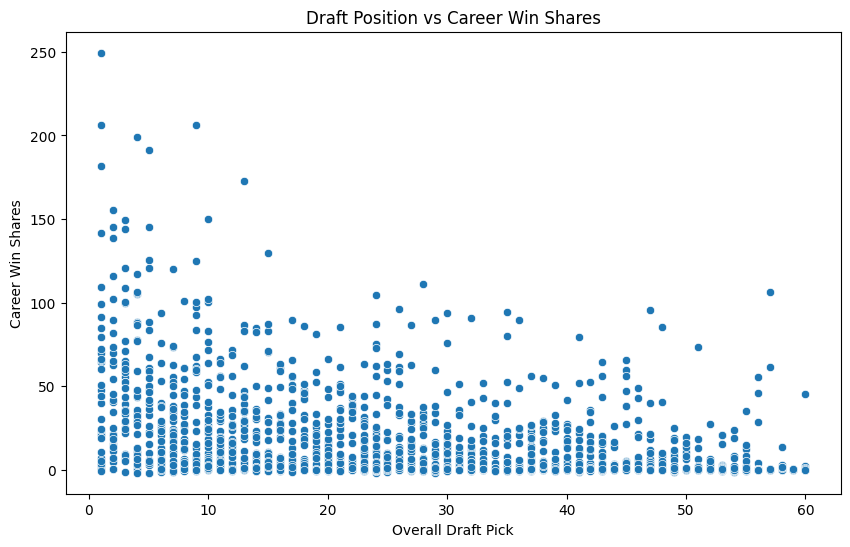

In [47]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='overall_pick',
    y='win_shares'
)

plt.title('Draft Position vs Career Win Shares')
plt.xlabel('Overall Draft Pick')
plt.ylabel('Career Win Shares')

plt.show()

## Visualization Analysis: Draft Position vs Career Success

The scatter plot reveals a moderate negative relationship between draft position and career Win Shares.

Key Findings:

- Earlier draft selections generally achieve higher career value.
- Most elite careers are concentrated among Top-15 selections.
- Significant variability exists at every draft position.
- Several late-round selections substantially outperform expectations.

Business Insight:

Draft position improves the probability of selecting successful players, but scouting accuracy remains critical because player outcomes vary considerably even among similarly drafted prospects.

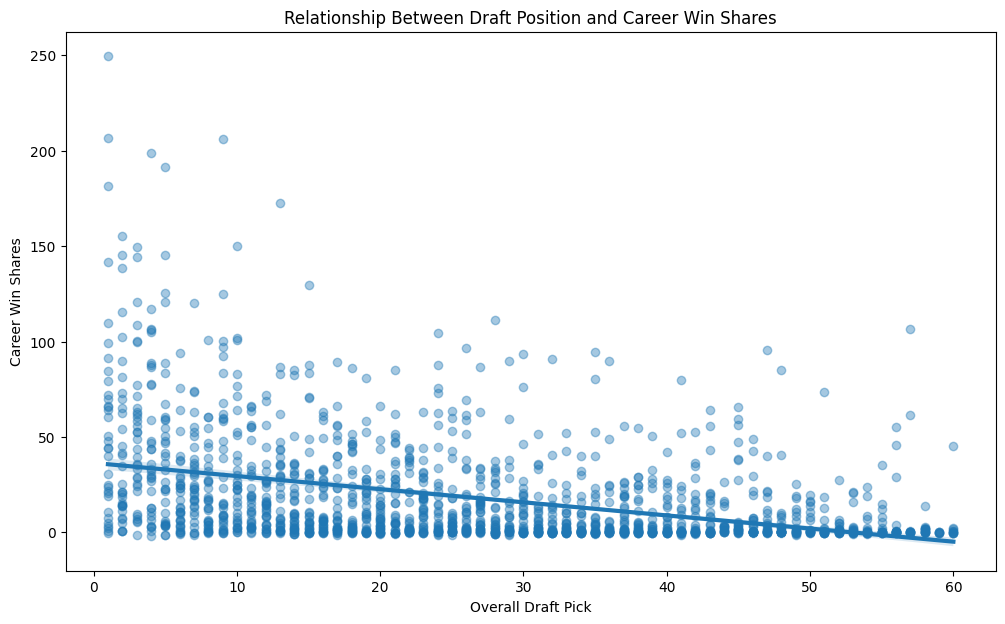

In [48]:
plt.figure(figsize=(12,7))

sns.regplot(
    data=df,
    x='overall_pick',
    y='win_shares',
    scatter_kws={'alpha':0.4},
    line_kws={'linewidth':3}
)

plt.title('Relationship Between Draft Position and Career Win Shares')
plt.xlabel('Overall Draft Pick')
plt.ylabel('Career Win Shares')

plt.show()

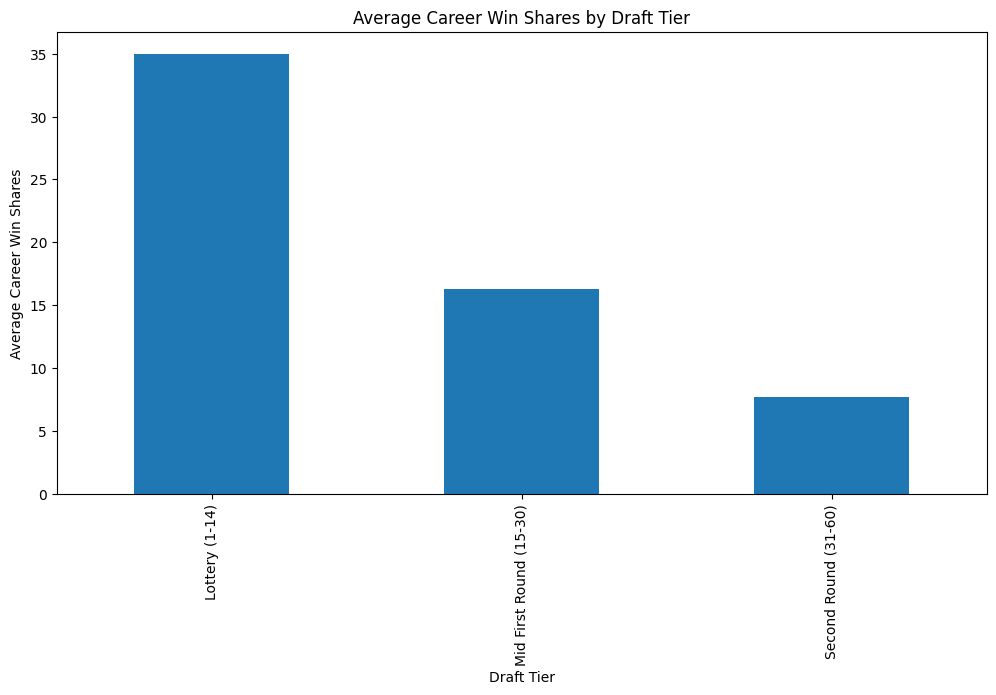

In [49]:
plt.figure(figsize=(12,6))

draft_tiers = pd.cut(
    df['overall_pick'],
    bins=[0,14,30,60],
    labels=['Lottery (1-14)','Mid First Round (15-30)','Second Round (31-60)']
)

tier_ws = df.groupby(draft_tiers)['win_shares'].mean()

tier_ws.plot(kind='bar')

plt.title('Average Career Win Shares by Draft Tier')
plt.xlabel('Draft Tier')
plt.ylabel('Average Career Win Shares')

plt.show()

## Draft Tier Analysis

Average Career Win Shares by Draft Tier:

- Lottery Picks (1-14): ~35 Win Shares
- Mid First Round (15-30): ~16 Win Shares
- Second Round (31-60): ~8 Win Shares

Key Findings:

- Lottery selections generate the highest average career value.
- Mid-first-round players produce approximately half the value of lottery picks.
- Second-round selections generate the lowest average career value.

Business Insight:

Draft capital matters significantly. Teams holding lottery picks possess a substantial statistical advantage in acquiring high-value NBA talent.

# Feature Engineering

In [50]:
df['draft_tier'] = pd.cut(
    df['overall_pick'],
    bins=[0, 14, 30, 60],
    labels=[
        'Lottery',
        'Mid First Round',
        'Second Round'
    ]
)

df[['overall_pick', 'draft_tier']].head(10)

,overall_pick,draft_tier
0,1,Lottery
1,2,Lottery
2,3,Lottery
3,4,Lottery
4,5,Lottery
5,6,Lottery
6,7,Lottery
7,8,Lottery
8,9,Lottery
9,10,Lottery


In [51]:
df['success_category'] = pd.cut(
    df['win_shares'],
    bins=[-100, 10, 50, 100, 300],
    labels=[
        'Low Impact',
        'Role Player',
        'Star',
        'Elite'
    ]
)

df[['player', 'win_shares', 'success_category']].head(15)

,player,win_shares,success_category
0,Pervis Ellison,21.8,Role Player
1,Danny Ferry,34.8,Role Player
2,Sean Elliott,55.7,Star
3,Glen Rice,88.7,Star
4,J.R. Reid,22.5,Role Player
5,Stacey King,10.9,Role Player
6,George McCloud,24.6,Role Player
7,Randy White,1.9,Low Impact
8,Tom Hammonds,14.7,Role Player
9,Pooh Richardson,26.7,Role Player


In [52]:
df['career_length_category'] = pd.cut(
    df['years_active'],
    bins=[0, 5, 10, 15, 30],
    labels=[
        'Short Career',
        'Average Career',
        'Long Career',
        'Legendary Longevity'
    ]
)

df[['player', 'years_active', 'career_length_category']].head()

,player,years_active,career_length_category
0,Pervis Ellison,11.0,Long Career
1,Danny Ferry,13.0,Long Career
2,Sean Elliott,12.0,Long Career
3,Glen Rice,15.0,Long Career
4,J.R. Reid,11.0,Long Career


In [53]:
df['draft_value_score'] = (
    df['win_shares'] /
    df['overall_pick']
)

df[['player',
     'overall_pick',
     'win_shares',
     'draft_value_score']].head()

,player,overall_pick,win_shares,draft_value_score
0,Pervis Ellison,1,21.8,21.800000
1,Danny Ferry,2,34.8,17.400000
2,Sean Elliott,3,55.7,18.566667
3,Glen Rice,4,88.7,22.175000
4,J.R. Reid,5,22.5,4.500000


In [54]:
draft_steals = df[
    ['player',
     'overall_pick',
     'win_shares',
     'draft_value_score']
].copy()

draft_steals = draft_steals.dropna()

draft_steals = draft_steals.sort_values(
    by='draft_value_score',
    ascending=False
)

draft_steals.head(15)

,player,overall_pick,win_shares,draft_value_score
785,LeBron James,1,249.5,249.50
440,Tim Duncan,1,206.4,206.40
162,Shaquille O'Neal,1,181.7,181.70
843,Dwight Howard,1,141.7,141.70
555,Elton Brand,1,109.6,109.60
382,Allen Iverson,1,99.0,99.00
1322,Anthony Davis,1,91.3,91.30
216,Chris Webber,1,84.7,84.70
1142,Blake Griffin,1,79.3,79.30
1023,Kevin Durant,2,155.2,77.60


In [55]:
df['success_category'].value_counts()

success_category
Low Impact     978
Role Player    505
Star           149
Elite           37
Name: count, dtype: int64

In [56]:
df['draft_tier'].value_counts()

draft_tier
Second Round       934
Mid First Round    526
Lottery            462
Name: count, dtype: int64

In [59]:
import os

print(os.getcwd())

print(os.listdir())

print(os.listdir("data"))

C:\Users\ASUS\OneDrive\Documents\data analytics projects\NBA-Draft-Analytics
['.git', 'dashboard', 'data', 'excel', 'frontend', 'notebooks', 'README.md', 'reports', 'sql']
['dataset_notes.md', 'processed', 'raw']


In [60]:
df.to_csv(
    r"C:\Users\ASUS\OneDrive\Documents\data analytics projects\NBA-Draft-Analytics\data\processed\nba_draft_analytics_dataset.csv",
    index=False
)

print("Analytics dataset exported successfully.")

Analytics dataset exported successfully.


In [61]:
df.columns.tolist()

['id',
 'year',
 'rank',
 'overall_pick',
 'team',
 'player',
 'college',
 'years_active',
 'games',
 'minutes_played',
 'points',
 'total_rebounds',
 'assists',
 'field_goal_percentage',
 '3_point_percentage',
 'free_throw_percentage',
 'average_minutes_played',
 'points_per_game',
 'average_total_rebounds',
 'average_assists',
 'win_shares',
 'win_shares_per_48_minutes',
 'box_plus_minus',
 'value_over_replacement',
 'draft_tier',
 'success_category',
 'career_length_category',
 'draft_value_score']